## EDA

In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [243]:
df = pd.read_csv("../../datasets/raw/titanic_train.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [244]:
print(df.shape)
print(df.columns)
print(df.info())

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


- Age and Cabin column with missing data

## Visualization
-----------------
**Survival Rate**

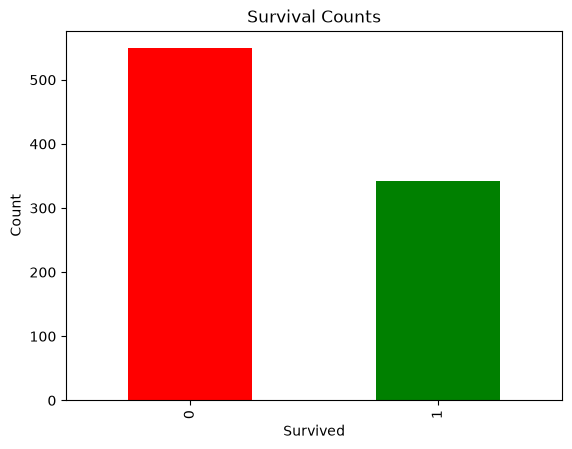

In [245]:
survived = df["Survived"].value_counts()
survived.plot(kind="bar", color=["red", "green"])
plt.title("Survival Counts")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

**Survival Rate by Sex and Class**

      Sex  Pclass  Survived
0  female       1  0.968085
1  female       2  0.921053
2  female       3  0.500000
3    male       1  0.368852
4    male       2  0.157407
5    male       3  0.135447


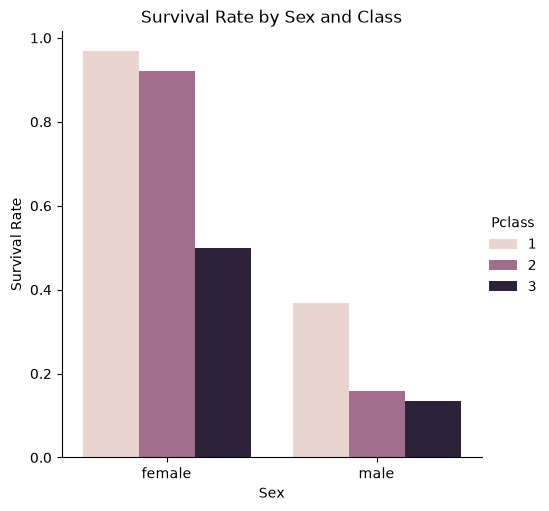

In [246]:
sex_survival = df.groupby(["Sex", "Pclass"])["Survived"].mean().reset_index()
print(sex_survival)

sns.catplot(data=sex_survival, x="Sex", y="Survived", hue="Pclass", kind="bar")
plt.title("Survival Rate by Sex and Class")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

**Inspecting Sex and Pclass**

In [247]:
sex_class = (
    df.groupby(["Sex", "Pclass"])["Survived"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Total", "mean": "Survival Rate"})
)
print(sex_class)

               Total  Survival Rate
Sex    Pclass                      
female 1          94       0.968085
       2          76       0.921053
       3         144       0.500000
male   1         122       0.368852
       2         108       0.157407
       3         347       0.135447


## Survival rate by Age

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
                 Total  Survival Rate
Age      Sex                         
(60, 80] female      3       1.000000
         male       19       0.105263
(45, 60] female     27       0.851852
         male       54       0.185185
(35, 45] female     43       0.720930
         male       71       0.197183
(18, 35] female    120       0.783333
         male      238       0.180672
(12, 18] female     36       0.750000
         male       34       0.088235
(0, 12]  female     32       0.593750
         male       37       0.567568


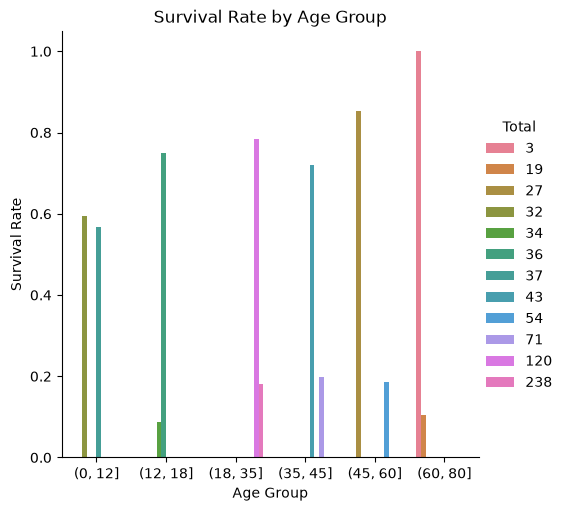

In [248]:
print(df['Age'].describe())
age_survival = (
    df
    .groupby([pd.cut(df["Age"], bins=[0, 12, 18, 35, 45, 60, 80]), "Sex"])["Survived"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Total", "mean": "Survival Rate"})
    .sort_values(by="Age", ascending=False)
)
print(age_survival)
bar_colors = sns.color_palette("husl", len(age_survival))
sns.catplot(data=age_survival, x="Age", y="Survival Rate", hue="Total", kind="bar",  palette=bar_colors)
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()


**Survival rate by Fare and Class**

         Fare  Pclass  Survived
0     (0, 50]       1  0.472222
1     (0, 50]       2  0.497076
2     (0, 50]       3  0.238901
3   (50, 100]       1  0.732558
4   (50, 100]       2  0.285714
5   (50, 100]       3  0.357143
6  (100, 200]       1  0.757576
7  (200, 500]       1  0.647059


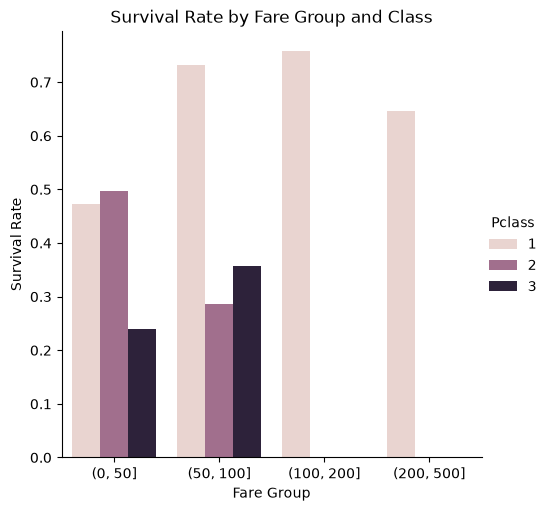

In [249]:
fare_survival = df.groupby([pd.cut(df["Fare"], bins=[0, 50, 100, 200, 500]), "Pclass"])["Survived"].mean().reset_index()
print(fare_survival)
sns.catplot(data=fare_survival, x="Fare", y="Survived", hue="Pclass", kind="bar")
plt.title("Survival Rate by Fare Group and Class")
plt.xlabel("Fare Group")
plt.ylabel("Survival Rate")
plt.show()

- Checking correlation between Fare and Survival

In [250]:
print("Correlation between Fare and Survived:")
print(df['Fare'].corr(
    df['Survived'].groupby(
        pd.cut(df['Fare'], bins=[0, 50, 100, 200, 500])
    ).transform('mean')
))

Correlation between Fare and Survived:
0.798424905674086


**Detailed summary on survival rate**

In [251]:
summary = (
    df
    .groupby(['Pclass','Sex', 'Embarked'])['Survived']
    .agg(['mean','count'])
    .rename(columns={'mean':'SurvivalRate', 'count':'PassengerCount'})
    .sort_values(by='SurvivalRate', ascending=False)
)
print("Overall Summary:")
print(summary)

Overall Summary:
                        SurvivalRate  PassengerCount
Pclass Sex    Embarked                              
1      female Q             1.000000               1
2      female Q             1.000000               2
              C             1.000000               7
1      female C             0.976744              43
              S             0.958333              48
2      female S             0.910448              67
3      female Q             0.727273              33
              C             0.652174              23
1      male   C             0.404762              42
3      female S             0.375000              88
1      male   S             0.354430              79
3      male   C             0.232558              43
2      male   C             0.200000              10
              S             0.154639              97
3      male   S             0.128302             265
              Q             0.076923              39
1      male   Q             0

--------------
## EDA Review
- **Sex** has a strong association with survival, with female passengers having a substantially higher survival rate than male passengers. Further inspection by passenger class shows that males outnumbered females across all three classes. However, despite this difference in passenger composition, females had higher survival rates than males within each class. This suggests that the relationship between sex and survival persists even after accounting for passenger class, with female passengers generally having a greater likelihood of survival than male passengers.

- **Age** 
**Survival was lowest among passengers over 60**, suggesting that older age was associated with a lower likelihood of survival.**Sex strongly differentiated survival across age groups**, with females having substantially higher survival rates than males across nearly every age group.Among **females**, survival remained relatively high across most age groups but declined among the oldest passengers.Among **males**, survival was low overall, although male children had higher survival rates than adult males.Overall, **age appears to be associated with survival, but its relationship is closely intertwined with sex and passenger class**. Therefore, differences in survival should not be attributed to age alone, as the effect of age may vary depending on a passenger's sex and class.

- **Embarkation** shows little apparent association with survival, although differences in passenger composition across embarkation points may influence the observed survival rates. Embarkation simply wasn't a major distinguishing factor in survival as compared to other variables like **Sex** and **Pclass**.
- **Passenger class (Pclass) was a major distinguishing factor in survival**, with both male and female passengers showing higher survival rates in 1st class, followed by 2nd class and then 3rd class.* **Females nevertheless maintained relatively higher survival rates than males across all three classes**, suggesting that the relationship between sex and survival persisted even when accounting for passenger class.The higher survival rates among 1st- and 2nd-class passengers may be partly explained by their **socioeconomic status and differences in access to safety**, such as cabin location and proximity to lifeboats. These factors may have affected how quickly passengers could access evacuation routes and respond to the emergency.However, these explanations should be considered **possible contributing factors rather than direct causal conclusions**, as the EDA only demonstrates associations between passenger class and survival.

- **Fare** appears to have a positive association with survival, but this relationship may largely reflect the relationship between fare and passenger class rather than a direct effect of fare on survival. Passengers who paid higher fares generally belonged to 1st- and 2nd-class groups, which had higher survival rates. Therefore, fare may serve more as an indicator of passenger class and socioeconomic status than as a direct determinant of survival.

---------
### Missing Data
- All data is accounted for except for column **Age** and **Cabin** with missing data.
* Drop column Cabin during modelling and engineer missing data for column Age; fillna(mean, median, .....)

